# <b> Lunes </b>

<b> probabilidad | ¿El estimador “ingenuo” realmente gana? Aquí quiero que veas el fenómeno mediante simulación. </b>

Supón que el verdadero alpha es:

$$ \mu=0.0003. $$

Realiza 5_000 experimentos. En cada experimento genera solamente 50 observaciones:

> r = np.random.normal(   loc=0.0003,scale=0.01,size=50)

Calcula:

> mu_hat = r.mean()

y un estimador shrinkage muy simple:

> mu_shrunk = 0.5 * mu_hat

Compara sobre los 5,000 experimentos:

$$ Bias,\qquad Variance,\qquad MSE $$

de ambos estimadores respecto al verdadero $\mu$.

Construye sólo:

| Estimator   | Bias | Variance | MSE |
| ----------- | ---: | -------: | --: |
| Sample mean |      |          |     |
| Shrunk mean |      |          |     |

Después repite cambiando únicamente:

size=1000

No optimices $ \lambda $ 

La pregunta importante es: ¿por qué shrinkage puede ser especialmente valioso con muestras pequeñas y perder parte de su ventaja conforme aumenta \(N\)?

Relaciona explícitamente tu explicación con:

$SE(μ^)∝ \frac{1}{ \sqrt{N}} N$
	​

In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(seed=42)

true_mu = 0.0003
sigma = 0.01
n_experimentos = 5_000

def comparar_estimadores(n_observaciones):
    # Cada fila representa un experimento distinto
    retornos = rng.normal(
        loc=true_mu,
        scale=sigma,
        size=(n_experimentos, n_observaciones)
    )

    # Un mu_hat por experimento
    mu_hat = retornos.mean(axis=1)

    # Estimador shrinkage fijado por el enunciado
    mu_shrunk = 0.5 * mu_hat

    def metricas(estimador):
        return {
            "Bias": estimador.mean() - true_mu,
            "Variance": estimador.var(ddof=1),
            "MSE": ((estimador - true_mu) ** 2).mean()
        }

    return pd.DataFrame(
        {
            "Sample mean": metricas(mu_hat),
            "Shrunk mean": metricas(mu_shrunk)
        }
    ).T
resultados_50 = comparar_estimadores(n_observaciones=50)
resultados_50

,Bias,Variance,MSE
Sample mean,0.000001,2.003386e-06,2.002987e-06
Shrunk mean,-0.000149,5.008464e-07,5.230453e-07


In [ ]:
resultados_1000 = comparar_estimadores(n_observaciones=1000)
resultados_1000

,Bias,Variance,MSE
Sample mean,0.000008,1.000599e-07,1.001067e-07
Shrunk mean,-0.000146,2.501497e-08,4.630065e-08


: 

# Martes

<b> Research | Un resultado espectacular con poca información. Compara dos estrategias ficticias: </b>

$$ A:\quad\hat\mu=12\text{ bps},\ SE=8 $$ $$ B:\quad\hat\mu=7\text{ bps},\ SE=2. $$

Para ambas usa el mismo prior:

$$ \mu\sim N(0,5^2)\text{ bps}. $$

Escribe una función pequeña:

>`def posterior_normal(mu_prior, sd_prior, mu_hat, se):`
>
>       `...`

que devuelva:

- posterior_mean
- posterior_sd
- P(mu > 0)

Usa:  $$\sigma_{\text{post}}^2 = \left( \frac{1}{\sigma_0^2} + \frac{1}{SE^2} \right)^{-1}.$$

|                |  A |  B |
| -------------- | -: | -: |
| Raw estimate   | 12 |  7 |
| SE             |  8 |  2 |
| Posterior mean |    |    |
| Posterior SD   |    |    |
| \(P(\mu>0)\)   |    |    |


Ahora decide cuál de estas afirmaciones puedes defender:

$$ \text{“A tiene mayor estimated alpha”} $$

versus

$$ \text{“A tiene evidencia más fuerte de alpha”.} $$

No son equivalentes.  

- <b> R:  </b> A tiene el estimate puntual más alto, pero B tiene evidencia más confiable de alpha positivo.

Finalmente responde: ¿por qué ordenar estrategias únicamente por $ \hat\mu $  o  Sharpe observado favorece resultados extremos y potencialmente ruidosos? 

- <b> R: </b> Ordenar sólo por $\hat\mu $  o por Sharpe observado favorece resultados extremos porque ambos son estimaciones muestrales. Una estrategia con mucho ruido puede obtener un retorno o Sharpe excepcional por azar, especialmente con pocas observaciones; al elegir la cifra más alta, seleccionas también parte de ese ruido.

In [16]:
import numpy as np 
import pandas as pd 
from scipy.stats import norm
strate_a = np.array([12,8])
strate_b = np.array([7,2])
# prior data 
mu_prior = 0 
sigma_prior = 5

def posterior_normal(mu_prior, sd_prior, mu_hat, se):
    posterior_variance = 1 / (1 / sd_prior**2 +1 / se**2)

    posterior_mean = posterior_variance * (mu_prior / sd_prior**2 +mu_hat / se**2)

    posterior_sd = np.sqrt(posterior_variance)

    p_mu_positive = norm.cdf(posterior_mean / posterior_sd)

    return {
        "Raw estimate": mu_hat,
        "SE": se,
        "Posterior mean": posterior_mean,
        "Posterior SD": posterior_sd,
        "P(mu > 0)": p_mu_positive
    }

a =  posterior_normal(mu_prior, sigma_prior,strate_a[0], strate_a[1])
b = posterior_normal(mu_prior, sigma_prior,strate_b[0], strate_b[1])
df_resultados = pd.DataFrame([a, b], index = ['strategy_A', 'strategy_B'])
df_resultados

,Raw estimate,SE,Posterior mean,Posterior SD,P(mu > 0)
strategy_A,12,8,3.370787,4.239992,0.786693
strategy_B,7,2,6.034483,1.856953,0.999422


<b> Portfolio/Risk + Quant Desk | Una view también tiene incertidumbre. Regresa a tu arquitectura de escenarios: </b>

$$ (R,p)\rightarrow\text{Views}\rightarrow(R,q). $$

Tu Research Engine produce:

> “Equities deberían superar bonds durante el próximo mes.”

Una interfaz ingenua guarda:

>`view:`
>
>`E[R_equity - R_bond] >= 0`

Pero compara dos fuentes posibles.

Research A: 15 años de evidencia, múltiples regímenes, efecto estable.

Research B: 35 observaciones recientes, efecto grande pero muy inestable.

Ambas producen exactamente la misma restricción matemática.

Diseña ahora un contrato de view con sólo:

- statement
- constraint
- estimate
- uncertainty
- confidence
- as_of_time

<b>RESPUESTA </b> 

Significado de cada campo:
- statement: explicación humana de la hipótesis económica.
- constraint: traducción matemática que puede consumir el motor de escenarios.
- estimate: magnitud esperada, con unidades y horizonte.
- uncertainty: imprecisión de esa estimación; por ejemplo SE, intervalo o dispersión.
- confidence: peso/confiabilidad normalizada de la view.
- as_of_time: cuándo era válida la información.

view_A = {
    "statement": "Equities deberían superar bonds durante el próximo mes.",
    "constraint": "E[R_equity - R_bond] >= 0",
    "estimate": "+80 bps de retorno relativo esperado a 1 mes",
    "uncertainty": "SE = 15 bps",
    "confidence": 0.90,
    "as_of_time": "2026-09-15T09:00:00"
}

view_B = {
    "statement": "Equities deberían superar bonds durante el próximo mes.",
    "constraint": "E[R_equity - R_bond] >= 0",
    "estimate": "+80 bps de retorno relativo esperado a 1 mes",
    "uncertainty": "SE = 90 bps",
    "confidence": 0.35,
    "as_of_time": "2026-09-15T09:00:00"
}


Flujo : $$\begin{array}{c}\text{Historical distribution } p \\ + \quad \boxed{\text{view : direccion, magnitud} + \text{uncertainty}} \\ \downarrow \\ q. \end{array}$$

No implementes Entropy Pooling.

Responde en máximo cinco líneas:

¿por qué sería conceptualmente incorrecto que Research A y Research B deformaran $ p $ exactamente en la misma magnitud sólo porque expresan la misma dirección de view? 

Research A y B expresan la misma dirección, pero A debería deformar $ p $ más porque cuenta con evidencia estable y precisa. B debe deformarla poco porque su efecto es incierto; la dirección no basta para justificar el mismo cambio en $ q $.



Finalmente propón qué debería ocurrir en los extremos:

$$ confidence\rightarrow0 \quad\Rightarrow\quad q\rightarrow ? $$ $$ confidence\rightarrow1 \quad\Rightarrow\quad q\rightarrow ? $$

No necesitas una fórmula; interpreta económicamente ambos límites.

cuando la confianza es 0  : La view se ignora: conservas la distribución histórica.

cuando la confianza es alta : una distribución fuertemente consistente con la view.

# MIERCOLES 

<b> Estadística | Mismo mean/vol, distinto riesgo. </b>

Genera:

> `np.random.seed(42)`
>
>`normal = np.random.normal(0.0005, 0.01, 100_000)`
>
>`t_raw = np.random.standard_t(df=3, size=100_000)`
>
>`fat_tail = ((t_raw - t_raw.mean()) / t_raw.std() * 0.01 + 0.0005)`

Comprueba que ambas muestras tienen aproximadamente:

μ=5 bps ,σ=1%.

Calcula

| Distribution | Mean | Vol | Skew | Kurtosis | 1% quantile | Worst return |
| ------------ | ---: | --: | ---: | -------: | ----------: | -----------: |

No hagas optimización ni ajustes adicionales.

Después responde:

Si mean y variance son prácticamente iguales, ¿por qué un Portfolio/Risk Engine podría considerar estas dos distribuciones completamente diferentes?

- <b> R :  </b> Aunque ambas distribuciones tienen mean y volatilidad similares, presentan riesgo de cola distinto. fat_tail concentra más probabilidad en pérdidas extremas, visible en su kurtosis, cuantíl al 1% y peor retorno. Por eso un Portfolio/Risk Engine no debería asignarles el mismo riesgo ni el mismo capital: $ (\hat{\mu},\hat{\Sigma}) $ pierde información sobre forma de la distribución, asimetría y riesgo de cola.

Y conecta el resultado con esta compresión:

$$ R_{1:T} \longrightarrow (\hat\mu,\hat\Sigma). $$

¿Qué estructura relevante desapareció?

- <B> R: </b>La compresión $ R_{1:T}\rightarrow(\hat{\mu},\hat{\Sigma}) $ reduce toda la historia de retornos a promedio y co-movimiento lineal. En este caso oculta que fat_tail tiene pérdidas extremas mucho más probables que una normal, aunque ambas tengan la misma media y volatilidad. Por tanto, un motor media-varianza trataría riesgos estructuralmente distintos como si fueran equivalentes.

In [21]:
import numpy as np 
import pandas as pd 
import scipy.stats as stats
np.random.seed(42)
normal = np.random.normal(0.0005, 0.01, 100_000)
t_raw = np.random.standard_t(df=3, size=100_000)
fat_tail = ((t_raw - t_raw.mean()) / t_raw.std() * 0.01 + 0.0005)

print('media de la normal: ', normal.mean())
print('desviacion de la normal:', normal.std())
print('media de la distribucion fat tail', fat_tail.mean())
print('desviacion de la distribucion fat tail:', fat_tail.std())

df = pd.DataFrame({'Distribucion': ['normal', 'fat tail'], 
                   'mean' : [normal.mean(), fat_tail.mean()], 
                   'vol': [normal.std(), fat_tail.std()], 
                   'skew' : [stats.skew(normal), stats.skew(fat_tail)], 
                   'kurtosis' : [stats.kurtosis(normal), stats.kurtosis(fat_tail)], 
                   '1% quantile' : [np.quantile(normal, 0.01), np.quantile(fat_tail, 0.01)], 
                   'Worst return' : [normal.min(), fat_tail.min()]})
df

media de la normal:  0.0005096686814094961
desviacion de la normal: 0.010009009542948904
media de la distribucion fat tail 0.0005
desviacion de la distribucion fat tail: 0.01


,Distribucion,mean,vol,skew,kurtosis,1% quantile,Worst return
0,normal,0.00051,0.010009,-0.001760,-0.008037,-0.022847,-0.044156
1,fat tail,0.00050,0.010000,4.085093,361.366433,-0.024974,-0.320657


In [22]:
a =  (5 * .23)  + (7 * .09 ) + ( 3 * .32 ) + (2 * .30)  + (0 * .11) 
a

3.3400000000000003

<b> Portfolio + Quant Desk | De point forecast a escenarios. </b>

Tu Alpha Engine actualmente podría producir algo como: 

- symbol: SPY
- horizon: 1D
- expected_return: +8 bps
- standard_error: 5 bps

Diseña ahora una interfaz alternativa basada en cinco escenarios:

| Scenario | Return \(R_s\) | Probability \(p_s\) |
| -------- | -------------: | ------------------: |
| 1        |              5 |                  .23 |
| 2        |              7 |                  .09 |
| 3        |              3 |                  .32 |
| 4        |              2 |                  .30 |
| 5        |              0 |                  .11 |

Tú eliges valores razonables, pero exige: $ \sum_s p_s = 1 $
Después calcula:  $ E_p[R] = ∑_i(p_sR_s) $

- $E_p[R]: $  3.34 bps

Ahora introduce una view de Research:

“Ha aumentado la probabilidad de un escenario negativo fuerte.”

No cambies los retornos \(R_s\).

Modifica únicamente las probabilidades:

$$ p\rightarrow q $$

manteniendo:

$$ \sum_s q_s=1. $$

Calcula:

$$ E_p[R] \qquad\text{vs}\qquad E_q[R]. $$

Finalmente responde:

¿qué diferencia conceptual existe entre cambiar \(R\) y cambiar \(p\)?

Tu respuesta debe distinguir:

$$ \boxed{\text{qué escenarios considero posibles}} $$

de
$$ \boxed{\text{que tan plausibles considero esos escenarios}} $$


- <b>R:  </b>
   - Cambiar $R $: cambias el conjunto o magnitud de los escenarios posibles. Por ejemplo, introducir una caída de -12 bps que antes no existía.
   - Cambiar $ p $: mantienes exactamente los mismos escenarios, pero cambias tu creencia sobre cuál es más probable.


# JUEVES

<b> portfolio | Observa qué hace realmente Entropy Pooling </b>

Usar:

> `import numpy as np`
>
>`from scipy.optimize import minimize`
>
>`R = np.array([-0.04, -0.01, 0.02, 0.06])`
>
>`p = np.array([0.40, 0.30, 0.20, 0.10])`

Implementa:

> `def kl(q, p):`
>
>    `return np.sum(q * np.log(q / p))`

y resuelve:

$$ \min_qD_{KL}(q\|p) $$

sujeto ahora a la igualdad:

$$ E_q[R]=1\%. $$

Incluye también:

$$ \sum_iq_i=1,\qquad q_i>0. $$

Reporta únicamente:

|                 | Prior $p$ | Posterior $q^{*}$ |
| --------------- | ----------: | ----------------: |
| Scenario -4%    |             |                   |
| Scenario -1%    |             |                   |
| Scenario +2%    |             |                   |
| Scenario +6%    |             |                   |
| Expected return |             |                   |
| KL vs prior     |             |                   |

Después observa qué probabilidades cambió el optimizer.

No interpretes el resultado como:

“EP encontró la verdadera distribución.”

Explica por qué la interpretación correcta es más cercana a:

$$ \boxed{\text{la distribución más cercana a }p \text{ que hace compatible mi view}.} $$

Finalmente cambia únicamente la view:

$$ E_q[R]=4\% $$

y vuelve a resolver.

¿Qué ocurre con $ D_{KL}(q^*\|p) $?

Explica por qué una view más agresiva requiere normalmente una modificación mayor del prior.

- <b>R: </b> la view es mucho más agresiva que la de \(1\%\), así que exige una redistribución mucho mayor desde \(p\) hacia \(q\). Por eso el KL aumenta de forma importante: el prior debe deformarse más para ser compatible con la nueva view.

In [7]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd 
# distribucion de rendimientos 
R = np.array([-0.04, -0.01, 0.02, 0.06])
# probabilidades apriori
p = np.array([0.40, 0.30, 0.20, 0.10])

# declaramos restricciones 
constraints = [{'type': 'eq',
               'fun': lambda q : np.sum(q) - 1 }, 
                {'type' : 'eq', 
                 'fun': lambda q: q @ R - 0.01} ]




# funcion de divergencia kullback-leider 
def kl(q, p):
    return np.sum(q * np.log(q / p))



bounds = [(1e-12, 1)] * len(p)
# buscando el minimo q* 
resultado = minimize(
    fun=lambda q: kl(q, p),
    x0=p.copy(),         # q inicial: el prior
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

q_star = resultado.x
df = pd.DataFrame({'prior p' :[p[0], p[1], p[2], p[3], p @ R, '0.0'], 
                    'Posteriori q' : [q_star[0], q_star[1], q_star[2], q_star[3], q_star @ p, kl(q_star, p)]}, 
                    index = [ "Scenario -4%","Scenario -1%","Scenario +2%","Scenario +6%","Expected return","KL vs prior"])

df

,prior p,Posteriori q
Scenario -4%,0.4,0.211523
Scenario -1%,0.3,0.255392
Scenario +2%,0.2,0.274256
Scenario +6%,0.1,0.258829
Expected return,-0.009,0.241961
KL vs prior,0.0,0.156859


In [8]:
# con E_q[R] = 4%
# declaramos restricciones 
constraints = [{'type': 'eq',
               'fun': lambda q : np.sum(q) - 1 }, 
                {'type' : 'eq', 
                 'fun': lambda q: q @ R - 0.04} ]




# funcion de divergencia kullback-leider 
def kl(q, p):
    return np.sum(q * np.log(q / p))



bounds = [(1e-12, 1)] * len(p)
# buscando el minimo q* 
resultado = minimize(
    fun=lambda q: kl(q, p),
    x0=p.copy(),         # q inicial: el prior
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

q_star = resultado.x
df = pd.DataFrame({'prior p' :[p[0], p[1], p[2], p[3], p @ R, '0.0'], 
                    'Posteriori q' : [q_star[0], q_star[1], q_star[2], q_star[3], q_star @ p, kl(q_star, p)]}, 
                    index = [ "Scenario -4%","Scenario -1%","Scenario +2%","Scenario +6%","Expected return","KL vs prior"])

df

,prior p,Posteriori q
Scenario -4%,0.4,0.037326
Scenario -1%,0.3,0.098978
Scenario +2%,0.2,0.233473
Scenario +6%,0.1,0.630223
Expected return,-0.009,0.154341
KL vs prior,0.0,0.998025


<b> Research + Quant Desk | ¿Quién tiene permiso de modificar \(p\)? </b>

Tu Portfolio Engine recibe:

$$ (R,p) $$

de un Scenario Engine.

Un researcher propone:

“Creo que durante el próximo mes aumenta la probabilidad de downside en equities.”

Diseña el flujo mínimo:

$$ \text{Scenario Engine} \rightarrow(R,p) \rightarrow \boxed{\text{Research View}} \rightarrow \boxed{\text{View Processor}} \rightarrow (R,q) \rightarrow \text{Portfolio Engine}. $$

- <b> RESPUESTA </b> 
  -  $ \text{Scenario Engine} \rightarrow(R,p) \rightarrow \text{Research View} \rightarrow \boxed{q^{*}= \arg\min_q D_{KL}(q\|p) \text{ sujeto a la view}} \rightarrow (R,q^{*}) \rightarrow \text{Portfolio Engine}$ 
  - A partir de $ (R,q) $, sí puedes calcular riesgo de escenarios: 
    -  E_q[R] 
    - Var_q(R)
    - text{VaR}
    - Expected Shortfall 
 - La raíz de $ \operatorname{Var}_q(R) $  es volatilidad bajo $ q $ , no error estándar de $ \mu_q $ .
Entonces la incertidumbre epistemológica (“¿qué tan confiable es mi view?”) entra antes, desde Research. El riesgo de escenarios (“¿qué pérdidas son plausibles bajo \(q\)?”) se evalúa después, antes o dentro de Portfolio/Risk. 

Ahora define sólo estos campos para una view:

- `view_id`
- `as_of_time`
- `target`
- `constraint`
- `confidence`
- `evidence_reference`
- `expiry`

Después decide quién no debería poder hacer directamente esto:

p[bad_scenarios] *= 2

y explica por qué.


 - <b>Respuesta </b>
    - Research no debería modificar directamente  <b> p </b>, y tampoco Portfolio, Risk ni Execution. Research debe proponer una view mediante el contrato; el View Processor es quien transforma formalmente: $ (R,p) \rightarrow (R,q) $ 
    
    - La distribución prior \(p\) debe permanecer inmutable y trazable. Multiplicar pesos directamente:
         - puede romper $ \sum p_s=1 $;
         - omite confidence, expiry y evidencia;
         - evita el ajuste mínimo y coherente vía KL;
         - hace imposible auditar qué view provocó cada cambio.
El Scenario Engine es dueño de generar/guardar el prior  $ p $. El View Processor puede producir un nuevo $ q $, pero no debe sobrescribir silenciosamente $ p $.

Tu Research Governance exige además registrar:

$$ D_{KL}(q\|p). $$

Propón tres estados conceptuales:
- LOW DISTORTION: la view es ampliamente compatible con el prior; $ q $ repondera los escenarios sólo de forma marginal.
- MODERATE DISTORTION: la view produce una reponderación material, pero los escenarios relevantes aún conservan pesos plausibles y la modificación está respaldada por evidencia suficiente.
- HIGH DISTORTION: la view entra en tensión fuerte con el prior; $ q $ concentra o elimina de facto probabilidades de forma sustancial. Requiere revisión de evidencia, confianza, vencimiento y posible aprobación de Risk/Governance.
En un desk serio, los umbrales numéricos se calibran posteriormente usando el historial de KL de tus propias views, no usando “1” como límite teórico.

No inventes thresholds numéricos todavía.

La pregunta final es:

si una view aparentemente razonable necesita una enorme distorsión de $ p $  para cumplirse, qué deberías cuestionar primero: el optimizer, el prior, la view o la evidencia que sustenta la view?

No hay una respuesta única. Ordena tu diagnóstico y justifícalo.

- <b> RESPUESTA:  </b>
  1. View: verificar que la hipótesis, horizonte, unidades y constraint representan realmente lo que Research quiso afirmar; una view débil no debería imponerse como igualdad dura.  
  2. Evidencia: revisar OOS, tamaño de muestra, error estándar, estabilidad por régimen y confidence asignada.  
  3. Prior  $ p $: comprobar que los escenarios y probabilidades siguen siendo relevantes; quizá el prior es viejo o incompleto.  
  4. Optimizer y $ q^{*} $ : validar que se cumplan constraints, $ \sum q=1 $, $ q_i>0 $, el KL correcto y que la reponderación tenga sentido económico.

# </b> Viernes <b>

<b> Portfolio | Hard views vs. uncertain views </b>

>`import numpy as np`
>
> `from scipy.optimize import minimize`
>
>`R = np.array([-0.04, -0.01, 0.02, 0.06])`
>
>`p = np.array([0.40, 0.30, 0.20, 0.10])`

Research estima:

$$ E[R]=3\%. $$

En vez de imponer directamente

$$ E_q[R]=3\%, $$

crea tres niveles ficticios de confianza:

- LOW       25%
- MEDIUM    60%
- HIGH      90%

Para este ejercicio usa deliberadamente una regla sencilla:

$$ q_c=(1-c)p+cq^*, $$

donde $ q^{*} $ es la solución EP con la view completamente impuesta.

Calcula para cada confianza:

$$ E_{q_c}[R] $$

y

$$ D_{KL}(q_c\|p). $$

Entrega sólo:

| Confidence | \(E_q[R]\) | KL vs \(p\) |
| ---------- | ---------: | ----------: |
| 0%         |            |             |
| 25%        |            |             |
| 60%        |            |             |
| 90%        |            |             |
| 100%       |            |             |


Importante: no concluyas que esta interpolación es “la fórmula de Entropy Pooling para confidence”. La estamos usando como experimento pedagógico.

Ahora interpreta los límites:

$$ c\rightarrow0\Rightarrow q_c\rightarrow p $$ $$ c\rightarrow1\Rightarrow q_c\rightarrow q^*. $$

<b>Respuesta </b>
 - El factor de confianza $ c $  determina cuánto se desplaza la distribución intermedia $ q_c $ desde la distribución a priori  $p$ hacia $q^{*}$.  
 - Si $ c=0 $ , entonces:
$ q_c=p$ , por lo que la view se ignora y el prior no se modifica.  
 - A medida que $ c $ aumenta, se asigna más peso a $ q^{*}$. Si $\to1$, entonces:
     - $ q_c\to q^{*}$.
     - Aquí $q^{*}$ es la distribución que altera lo menos posible al prior $p$, medida mediante $D_{KL}(q\|p)$, pero cumple exactamente:
$ E_q[R]=3\% $. Por tanto, $ c $  separa la magnitud de la view —retorno esperado de 3%— de la confianza que se tiene en imponerla sobre el prior.

Pregunta central:

¿Qué diferencia existe entre “mi view dice +3%” y “tengo mucha confianza en que la distribución debe ser consistente con +3%”?

- La view responde “¿qué retorno espero?”; la confianza responde “¿cuánto estoy dispuesto a alterar el prior para actuar como si esa estimación fuera correcta?”.

Esto separa magnitud de la view de fuerza de la evidencia


In [4]:
import numpy as np 
import pandas as pd 
from scipy.optimize import minimize 
R = np.array([-0.04, -0.01, 0.02, 0.06])
p = np.array([0.40, 0.30, 0.20, 0.10 ])

# con E_q[R] = 3%
# declaramos restricciones 
constraints = [{'type': 'eq',
               'fun': lambda q : np.sum(q) - 1 }, 
                {'type' : 'eq', 
                 'fun': lambda q: q @ R - 0.03} ]

# funcion de divergencia kullback-leider 
def kl(q, p):
    return np.sum(q * np.log(q / p))

bounds = [(1e-12, 1)] * len(p)
# buscando el minimo q* 
resultado = minimize(
    fun=lambda q: kl(q, p),
    x0=p.copy(),         # q inicial: el prior
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)
q_star = resultado.x
confianza = [0.0,.25, .60, .90, 1 ]
resultados = []
for c in confianza: 
    q_c= (1 - c) * p + c * q_star
    retorno_esperado = q_c @ R
    kl_value =  kl(q_c, p)
    resultados.append({'Confianza' : c, 
                       'E_q[R]': retorno_esperado, 
                       "KL vs p": kl_value})
niveles = [
    "Sin confianza (0%)",
    "Poca confianza (25%)",
    "Media confianza (60%)",
    "Alta confianza (90%)",
    "Confianza completa (100%)",
]
tabla = pd.DataFrame(resultados , index = niveles )
tabla.index.name = 'nivel de confianza'
tabla

,Confianza,E_q[R],KL vs p
nivel de confianza,,,
Sin confianza (0%),0.00,-0.00900,0.000000
Poca confianza (25%),0.25,0.00075,0.048318
Media confianza (60%),0.60,0.01440,0.241849
Alta confianza (90%),0.90,0.02610,0.513965
Confianza completa (100%),1.00,0.03000,0.630378


<b> Research governance + Quant Desk | Una view debe poder morir </b>

> Tu Research Engine propone:
>
> View V017: durante el próximo mes, equities outperform bonds.

La evidencia inicial es:

- historical effect :       +2.8%
- recent effect:           +4.1%
- bootstrap P(effect>0) :    84%
- sample :                  126 observations

La view provoca:

$$ D_{KL}(q\|p)=0.31 $$

y el Portfolio Engine aumenta considerablemente equity exposure.

Una semana después aparece nueva evidencia:

- recent effect :           +0.4%
- bootstrap P(effect>0) :    54%

No recalcules el portfolio.

Diseña el ciclo de vida de V017 usando solamente:

- `PROPOSED`
- `ACTIVE`
- `WEAKENED`
- `REJECTED`
- `EXPIRED`

### <b> Respuesta </b>

| Estado | Qué significa | Transición posible |
|---|---|---|
| `PROPOSED` | La hipótesis existe, pero aún no está autorizada para afectar el posterior o portafolio. | Pasa a `ACTIVE` si la evidencia inicial supera el criterio definido. Pasa a `REJECTED` si falla antes de activarse. |
| `ACTIVE` | La view está vigente y tiene evidencia suficiente para afectar la distribución posterior. | Pasa a `WEAKENED` si la evidencia se deteriora; a `REJECTED` si cumple el criterio de muerte; a `EXPIRED` al terminar su horizonte. |
| `WEAKENED` | La evidencia perdió fuerza, pero todavía no refuta totalmente la hipótesis. | Puede volver a `ACTIVE` si evidencia nueva recupera fuerza; pasar a `REJECTED` si falla el criterio; o a `EXPIRED` por tiempo. |
| `REJECTED` | La evidencia falsó la view según un criterio definido antes. | Estado terminal: no se reactiva V017; una hipótesis nueva debe tener otro `view_id`. |
| `EXPIRED` | La view terminó por vencimiento temporal, no necesariamente porque fuera falsa. | Estado terminal; si se quiere continuar, se propone una nueva view. |

y define qué evidencia permitiría cada transición.

```mermaid
graph TD
    PROPOSED --> ACTIVE
    ACTIVE --> WEAKENED
    ACTIVE --> REJECTED
    WEAKENED --> EXPIRED
```


Después especifica qué debería guardar tu Quant Desk:

- `view_id`
- `hypothesis`
- `constraint`
- `confidence`
- `evidence_as_of`
- `prior_distribution_id`
- `posterior_distribution_id`
- `KL_distortion`
- `status`
- `kill_criterion`

Tu última tarea de la semana es escribir antes de ver más datos un kill criterion falsable para V017.

No vale:

> “La eliminamos si deja de funcionar.”

Debe parecerse conceptualmente a:

$$ \boxed{ \text{Si nueva evidencia OOS produce }X, \quad V017\rightarrow REJECTED. } $$

#### <b>RESPUESTA </b>
 - Un criterio de muerte falsable podría ser:
$ \boxed{
\text{Si dos actualizaciones OOS consecutivas producen }
P(\text{effect}>0)<50\%
\text{ y efecto reciente}\leq0,
\quad
V017\rightarrow\texttt{REJECTED}.
} $

Y responde finalmente:

Si una view pierde evidencia, ¿deberías cambiar $ R $ , modificar manualmente $ q $, reducir su confidence o borrar el histórico de la view?

Justifica la trazabilidad que debería conservar el desk.

 
Si una view pierde evidencia, no se debe cambiar directamente \(R\), porque \(R\) representa los escenarios de rendimiento definidos por el modelo o por los datos. La pérdida de evidencia de una hipótesis no implica por sí sola que los escenarios hayan cambiado.
Tampoco se debe modificar manualmente \(q\). La distribución posterior \(q\) debe resultar del proceso de Entropy Pooling y de las restricciones vigentes, no de una intervención discrecional.
Lo correcto es actualizar la evidencia de la view y cambiar su estado, por ejemplo de ACTIVE a WEAKENED. Bajo una política predefinida, este cambio puede reducir su confidence; después, cuando corresponda al ciclo de rebalanceo, se vuelve a construir el posterior y el Portfolio Engine puede reducir la exposición relacionada con esa view.
No debe borrarse el histórico. La view, su evidencia inicial, sus cambios de estado, su confianza previa, sus distribuciones prior/posterior y su criterio de muerte deben permanecer registrados. Una view debilitada o rechazada también es información útil: evita repetir hipótesis ya evaluadas y permite aprender qué señales perdieron poder económico.
Si V017 termina en REJECTED o EXPIRED, se pueden proponer nuevas views alternativas, pero con un nuevo identificador y sin reescribir la historia de V017.

# <b> Sabado </b>

<b >Código + estadística | Random split puede fabricar un gran modelo </b>

Genera una serie temporal:

Compara dos experimentos con exactamente el mismo modelo lineal.

A — Random split
- 80% train aleatorio
- 20% test aleatorio

B — Temporal split

- primer 80% → train
- último 20% → OOS

Reporta únicamente

| Split    | Train $ R^2 $  | Test  $ R^2 $  | Test correlation |
| -------- | ------------: | -----------: | ---------------: |
| Random   |               |              |                  |
| Temporal |               |              |                  |


Ahora inspecciona cuidadosamente:

> `df["rolling_mean"] = df["r"].rolling(20).mean()`

Si estás prediciendo $ r_{t+1} $, ¿hay leakage aquí?

- <b> RESPUESTA </b>

> Para predecir $ r_{t+1} $, rolling_mean no es leaky si la señal se construye al final de $ t $, porque incorpora sólo retornos desde $ t-19 $ hasta $t $. Sin embargo, un random split puede inflar las métricas al mezclar observaciones temporalmente cercanas entre train y test. La validez depende del timestamp de decisión: si la decisión se tomara antes de conocer $ r_t $ , entonces sí habría leakage y la media móvil debería desplazarse con `.shift(1)`.

Después cambia el target a:

$$ y_t=r_t. $$

¿Sigue siendo válida la misma feature?

La pregunta central es:

¿Por qué una feature no es “leaky” por naturaleza, sino en relación con target, timestamp de decisión y proceso real de disponibilidad del dato?

- <b> Respuesta </b>
> No. Si $ y_t=r_t $, la media móvil original contiene el propio target $ r_t $, por lo que introduce leakage si la predicción se debe realizar antes del retorno de $ t $. La validez de una feature depende del target, del timestamp de decisión y de cuándo la información estuvo realmente disponible; para predecir $ r_t $, la media móvil debe desplazarse un periodo.

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score 
np.random.seed(42)

n = 5000
r = np.zeros(n)

for t in range(1, n):
    r[t] = 0.25 * r[t-1] + np.random.normal(0, 0.01)

df = pd.DataFrame({"r": r})

df["lag1"] = df["r"].shift(1)
df["rolling_mean"] = df["r"].rolling(20).mean()
df["target"] = df["r"] #.shift(-1)

df = df.dropna()
X = df[['lag1', 'rolling_mean']]
y = df['target']
# experimento A
X_train_r, x_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.20, 
                                                            shuffle= True, random_state=42)

modelo_random = LinearRegression()
modelo_random.fit(X_train_r, y_train_r)
pred_train_r = modelo_random.predict(X_train_r)
pred_test_r = modelo_random.predict(x_test_r)
train_r2_random = r2_score(y_train_r, pred_train_r)
test_r2_random = r2_score(y_test_r, pred_test_r)
test_corr_random = np.corrcoef(y_test_r, pred_test_r)[0, 1]

# experimento B 
cutoff = int(len(df) * 0.80)
X_train_t = X.iloc[:cutoff]
X_test_t = X.iloc[cutoff:]
y_train_t = y.iloc[:cutoff]
y_test_t = y.iloc[cutoff:]
modelo_temporal = LinearRegression()
modelo_temporal.fit(X_train_t, y_train_t)
pred_train_t = modelo_temporal.predict(X_train_t)
pred_test_t = modelo_temporal.predict(X_test_t)
train_r2_temporal = r2_score(y_train_t, pred_train_t)
test_r2_temporal = r2_score(y_test_t, pred_test_t)
test_corr_temporal = np.corrcoef(y_test_t, pred_test_t)[0, 1]

# resultados 
resultados = pd.DataFrame({'train r^2': [train_r2_random,train_r2_temporal],
                    'test r^2': [test_r2_random , test_r2_temporal], 
                    'test correlation': [test_corr_random, test_corr_temporal], 
                    }, index= ['Random', 'Temporal'])
resultados.index.name = 'split'
resultados

,train r^2,test r^2,test correlation
split,,,
Random,0.082011,0.109231,0.333147
Temporal,0.085287,0.090357,0.300989


In [7]:
df

,r,lag1,rolling_mean,target
19,-0.009101,-0.000084,-0.001191,-0.009101
20,-0.016398,-0.009101,-0.002011,-0.016398
21,0.010557,-0.016398,-0.001731,0.010557
22,0.000381,0.010557,-0.001705,0.000381
23,0.000771,0.000381,-0.001989,0.000771
...,...,...,...,...
4995,-0.005180,0.005575,0.000498,-0.005180
4996,-0.001785,-0.005180,0.001352,-0.001785
4997,0.006668,-0.001785,0.001232,0.006668
4998,0.032796,0.006668,0.002701,0.032796


<b> Quant Desk + Research Governance | Diseña el contrato temporal de una feature </b>

Tu Alpha Engine recibe:

- symbol: SPY
- feature: realized_vol_30m
- value: 0.0132

Eso no es suficiente para reproducir qué sabía el modelo.

Diseña un registro mínimo usando:

- feature_name
- symbol
- observation_time
- available_time
- window_start
- window_end
- source
- value


<b> RESPUESTA</b>

| Variables   | Definicion  | Valor  |
| -------- | ------------: | -----------: | 
| feature_name| Metrica diseñada  |realized_vol_30m              |          
| symbol |       Ticket symbol del activo |        SPY      |  
| observation_time |   Timestamp congelado del momento en que se se recolectan los datos para el calculo la feature    |  9:30:00        |
| available_time   |  debe ser igual o posterior a `observation_time`, pues hay latencia de cálculo/publicación.    |  9:30:07        |
| window_start     |  inicio de los datos        |   9:00 : 00       |  
| window_end       |     último dato incluido.     |  9:30:00         |
| source           |    De donde proviene ese dato(s)     |    IBKR      |
| value            |    Valor calculado de esa feature      |       0.0132   |   


Ahora considera:

- observation_time = 10:30:00
- available_time   = 10:30:07
- decision_time    = 10:30:03

¿Puede el modelo utilizar esa observación?

Justifica usando:

$$ available\_time\le decision\_time. $$

<b> RESPUESTA </b> 
No puede usarse, porque:

10:30:07 $\nleq$ 10:30:03
La observación se publicó cuatro segundos después de que el modelo ya había tomado la decisión.

Después añade una revisión automática previa a cualquier backtest:

$$ \boxed{\text{POINT-IN-TIME VALIDATION}} $$

y define tres checks concretos que realizaría.

Uno debe detectar future data, otro revisions/backfills y otro mismatches de timestamps.

<b> RESPUESTA </b>

> una puerta automática que corre antes del backtest. Si cualquier check falla, el backtest se bloquea y registra la fila problemática.

| Check | Regla automática | Qué detecta |
|---|---|---|
| Future-data check | `available_time <= decision_time` para cada feature usada por cada decisión | Datos publicados o calculados después de que el modelo decidió. |
| Revision/backfill check | Usar sólo la versión del dato cuyo `revision_time` o `published_time` sea `<= decision_time`; guardar `source_version`/snapshot | Valores corregidos posteriormente, datos finales o backfilled que no existían en vivo. |
| Timestamp-consistency check | Verificar `window_start <= window_end <= observation_time <= available_time`, misma zona horaria, símbolo y frecuencia/horizonte compatibles | Ventanas mal alineadas, mezcla de UTC/local, targets incorrectos o features asociadas a la decisión equivocada. |

La idea es que no basta con que la feature tenga un valor razonable: debes demostrar que ese valor, esa versión concreta y su ventana de cálculo existían antes de cada decisión histórica.

Finalmente responde:

Tu backtest tiene Sharpe $ 2.1 $ . Descubres que una sola feature utilizaba datos publicados 20 segundos después de cada decisión. Al corregirlo, Sharpe cae a $ 0.4 $. ¿Debes intentar “recuperar” el Sharpe modificando el modelo?

Tu decisión sólo puede comenzar con:

$$ \boxed{\text{KILL}} \qquad\text{o}\qquad \boxed{\text{KEEP TESTING}}. $$

Justifica qué hipótesis estás evaluando ahora

> KILL. El Sharpe 2.1 no es evidencia válida porque dependía de una feature disponible 20 segundos después de la decisión; el backtest tenía leakage y su desempeño no era ejecutable. El Sharpe 0.4 es la única evidencia válida de esta versión del modelo. La hipótesis que queda por evaluar es si las features disponibles point-in-time, sin información futura y tras costes, conservan un edge económico OOS.

# DOMINGO 

<b >estadística | ¿Tu correlación es un parámetro o un estado? </b>

Simula dos regímenes:

Calcula solamente:

$$ \rho_{\text{full sample}} $$

y una rolling correlation de 60 observaciones:

Reporta:

| Estimación        | Correlación |
| ----------------- | ----------: |
| Primer régimen    |             |
| Segundo régimen   |             |
| Full sample       |             |
| Última rolling-60 |             |

Haz un gráfico de rolling_corr.

Ahora responde:

Si full-sample correlation da aproximadamente $ 0.5 $, ¿es correcto concluir que “la correlación entre A y B es 0.5”?

<b> RESPUESTA </b>

> No. La correlación full-sample de 0.5 describe el promedio histórico de ambos regímenes, pero no una relación estable ni necesariamente el estado actual del mercado. La correlación es condicional al régimen: cerca de 0.2 en normalidad y cerca de 0.8 bajo estrés. Usar 0.5 para riesgo puede subestimar la dependencia actual si estamos en estrés

Distingue:

$$ \boxed{\text{unconditional estimate}} $$

de $$ \boxed{\text{conditional dependence}} $$

Y una cuestión de research: ¿qué evidencia necesitarías antes de afirmar que existen realmente “dos regímenes”, en vez de estar viendo simplemente ruido muestral?
	​
- Persistencia: periodos de correlación alta o baja que duren varias observaciones; no picos aislados de la rolling correlation.
Separación estadística: que la correlación estimada en los supuestos regímenes sea materialmente distinta, con intervalos de confianza que no se solapen demasiado.
- Repetición OOS: que los dos patrones aparezcan en segmentos temporales no usados para definirlos, otros activos o nuevas crisis.
- Fundamentación económica: que el estado “estrés” coincida con variables externas plausibles, como volatilidad alta, drawdowns, spreads amplios o crisis de liquidez.
- Mejora verificable: que un modelo de correlación condicional/regime-switching prediga mejor o gestione mejor el riesgo fuera de muestra que una correlación única.

In [9]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 500
cov_normal = np.array([[1.0, 0.2],
                      [0.2, 1.0]])

cov_stress = np.array([[1.0, 0.8],
                       [0.8, 1.0]])
normal = np.random.multivariate_normal([0, 0], cov_normal, n)
stress = np.random.multivariate_normal([0, 0], cov_stress, n)
x = np.vstack([normal, stress])
df = pd.DataFrame(x, columns=["A", "B"])
normal_df = df.iloc[:n]   
stress_df = df.iloc[n:]
corr_normal = normal_df["A"].corr(normal_df["B"])
corr_stress = stress_df["A"].corr(stress_df["B"])
corr_full = df["A"].corr(df["B"])
df["rolling_corr"] = df["A"].rolling(60).corr(df["B"])
corr_ultima = df["rolling_corr"].iloc[-1]
regimen_metricas = pd.DataFrame({'correlacion' : 
                                 [corr_normal, corr_stress,corr_full,corr_ultima] },
                                index = ['Primer régimen','Segundo régimen',
                                        'Full sample','ultima rolling-60'])
regimen_metricas

,correlacion
Primer régimen,0.175503
Segundo régimen,0.768591
Full sample,0.468618
ultima rolling-60,0.833892


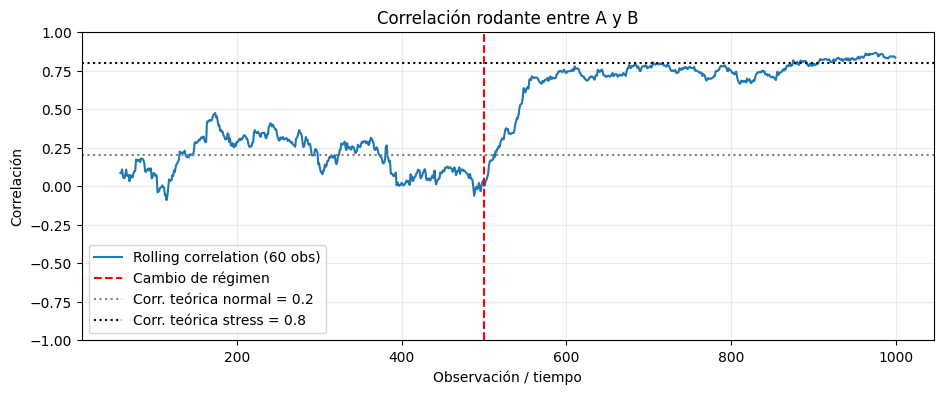

In [10]:
import matplotlib.pyplot as plt

df["rolling_corr"] = df["A"].rolling(window=60).corr(df["B"])

plt.figure(figsize=(11, 4))
plt.plot(df.index, df["rolling_corr"], label="Rolling correlation (60 obs)")
plt.axvline(n, color="red", linestyle="--", label="Cambio de régimen")
plt.axhline(0.2, color="gray", linestyle=":", label="Corr. teórica normal = 0.2")
plt.axhline(0.8, color="black", linestyle=":", label="Corr. teórica stress = 0.8")

plt.title("Correlación rodante entre A y B")
plt.xlabel("Observación / tiempo")
plt.ylabel("Correlación")
plt.ylim(-1, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.show()